# Marketing Analytics - Caso 2: FinTrust

In [3]:
%pip  install pandas scikit-learn matplotlib seaborn statsmodels -q

Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd

df1 = pd.read_csv('fintrust_bank_data.csv')
df2 = pd.read_csv('fintual_users_dataset_selected.csv')

### Utils

In [5]:
from scipy.stats import ttest_ind, mannwhitneyu

def statistical_tests(df, numVars=None):
    churned = df[df["Churn"] == 1]
    not_churned = df[df["Churn"] == 0]

    if numVars is None: 
        numeric_vars = [
            "logBalance", "NumProducts", "Tenure", "Complaints",
            "CreditUtilization", "InterestRateDiff"
        ]
    else:
        numeric_vars = numVars

    for var in numeric_vars:
        churned_values = churned[var].dropna()
        not_churned_values = not_churned[var].dropna()

        # Two-sample t-test
        t_stat, p_val = ttest_ind(churned_values, not_churned_values, equal_var=False)
        print(f"{var:<20} t-test p = {p_val:.4f}", end="  ")

        # Mann–Whitney (non-parametric)
        u_stat, p_val_u = mannwhitneyu(churned_values, not_churned_values, alternative="two-sided")
        print(f"mannwhitney p = {p_val_u:.4f}")

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

def churn_distributions(df, numVars=None, binVars=None):
    churned = df[df["Churn"] == 1]
    not_churned = df[df["Churn"] == 0]

    if numVars is None: 
        numeric_vars = [
            "logBalance", "NumProducts", "Tenure", "Complaints",
            "CreditUtilization", "InterestRateDiff"
        ]
    else:
        numeric_vars = numVars
        
    if binVars is None:
        binary_vars = ["DigitalUsage", "FeeIncrease", "Delinquency_30d"]
    else:
        binary_vars = binVars

    # === NUMERIC VARIABLES ===
    for var in numeric_vars:
        plt.figure(figsize=(12, 5))

        # Churned
        plt.subplot(1, 2, 1)
        sns.histplot(churned[var], color="red", kde=True, stat="count", bins=30)
        mean_c = churned[var].mean()
        median_c = churned[var].median()
        plt.axvline(mean_c, color="black", linestyle="--", linewidth=1.2, label=f"Media = {mean_c:.2f}")
        plt.axvline(median_c, color="blue", linestyle=":", linewidth=1.2, label=f"Mediana = {median_c:.2f}")
        plt.title(f"{var} - Churned")
        plt.xlabel(var)
        plt.ylabel("Count")
        plt.legend()

        # Not churned
        plt.subplot(1, 2, 2)
        sns.histplot(not_churned[var], color="green", kde=True, stat="count", bins=30)
        mean_nc = not_churned[var].mean()
        median_nc = not_churned[var].median()
        plt.axvline(mean_nc, color="black", linestyle="--", linewidth=1.2, label=f"Media = {mean_nc:.2f}")
        plt.axvline(median_nc, color="blue", linestyle=":", linewidth=1.2, label=f"Mediana = {median_nc:.2f}")
        plt.title(f"{var} - Not Churned")
        plt.xlabel(var)
        plt.ylabel("")
        plt.legend()

        plt.tight_layout()
        plt.show()

    # === BINARY / CATEGORICAL VARIABLES ===
    for var in binary_vars:
        plt.figure(figsize=(6, 4))
        sns.barplot(
            x=var,
            y="Churn",
            data=df,
            estimator=lambda x: sum(x) / len(x),
            errorbar=None,
            palette="viridis"
        )
        plt.title(f"Tasa de churn por {var}")
        plt.ylabel("Proporción de churn")
        plt.show()

    # === SEGMENT (si existe) ===
    if "Segment" in df.columns:
        plt.figure(figsize=(6, 4))
        sns.barplot(
            x="Segment",
            y="Churn",
            data=df,
            estimator=lambda x: sum(x) / len(x),
            errorbar=None,
            palette="coolwarm"
        )
        plt.title("Tasa de churn por segmento")
        plt.ylabel("Proporción de churn")
        plt.show()


### Parte 2

#### 2.1

/tmp/ipykernel_24518/3916523315.py:19: UserWarning: The palette list has more values (10) than needed (4), which may not be intended.
  ax = sns.barplot(x=["LowValue", "MidValue", "HighValue", "Total"], y=[churn_rate1, churn_rate2, churn_rate3, total], hue=["LowValue", "MidValue", "HighValue", "Total"], palette=sns.color_palette("pastel"))


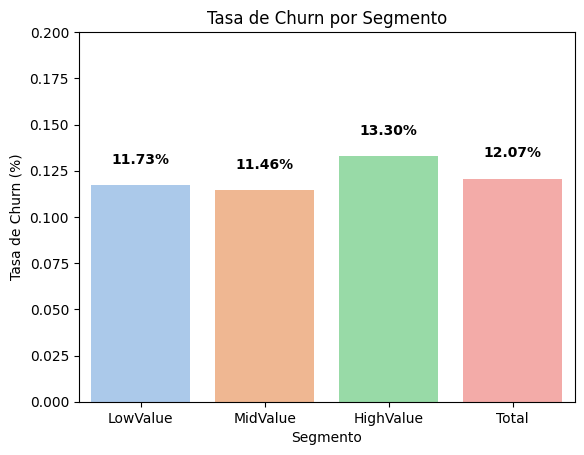

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
segment1 = df1[df1["Segment"] == "LowValue"]
segment2 = df1[df1["Segment"] == "MidValue"]
segment3 = df1[df1["Segment"] == "HighValue"]
# Data for plotting
labels = ["LowValue", "MidValue", "HighValue", "Total"]




# tasa de churn por segmento
total = df1["Churn"].mean()
churn_rate1 = segment1["Churn"].mean()
churn_rate2 = segment2["Churn"].mean()
churn_rate3 = segment3["Churn"].mean()
values = [churn_rate1, churn_rate2, churn_rate3, total]

ax = sns.barplot(x=["LowValue", "MidValue", "HighValue", "Total"], y=[churn_rate1, churn_rate2, churn_rate3, total], hue=["LowValue", "MidValue", "HighValue", "Total"], palette=sns.color_palette("pastel"))


# Add text labels above each bar
for i, v in enumerate(values):
    ax.text(
        i,                     
        v + 0.01,               
        f"{v:.2%}",             
        ha="center", va="bottom",
        fontsize=10, fontweight="bold"
    )
plt.ylim(0, .2)
plt.title("Tasa de Churn por Segmento")
plt.ylabel("Tasa de Churn (%)")
plt.xlabel("Segmento")
plt.show()



#### 2.2

In [8]:
# Cantidad de valores nulos por columna
missing_counts = df1.isnull().sum()
print("Valores nulos por columna:")
print(missing_counts)


Valores nulos por columna:
Segment              0
Balance              0
logBalance           0
NumProducts          0
DigitalUsage         0
Tenure               0
FeeIncrease          0
Complaints           0
Delinquency_30d      0
CreditUtilization    0
InterestRateDiff     0
Churn                0
dtype: int64


In [9]:
df1.describe()

,Balance,logBalance,NumProducts,DigitalUsage,Tenure,FeeIncrease,Complaints,Delinquency_30d,CreditUtilization,InterestRateDiff,Churn
count,4000.000000,4000.000000,4000.00000,4000.000000,4000.000000,4000.000000,4000.00000,4000.000000,4000.000000,4000.000000,4000.000000
mean,5237.943898,8.468444,2.49100,0.610750,60.186750,0.197750,0.29375,0.097250,0.285103,0.501348,0.120750
std,5119.172795,0.415822,1.11388,0.487641,34.487066,0.398352,0.55411,0.296335,0.159947,0.285617,0.325877
min,0.000000,0.000000,1.00000,0.000000,1.000000,0.000000,0.00000,0.000000,0.002778,0.000000,0.000000
25%,4000.900175,8.294525,2.00000,0.000000,30.000000,0.000000,0.00000,0.000000,0.159118,0.297334,0.000000
50%,4996.842936,8.516762,2.00000,1.000000,60.000000,0.000000,0.00000,0.000000,0.263126,0.494460,0.000000
75%,6059.688677,8.709579,3.00000,1.000000,90.000000,0.000000,1.00000,0.000000,0.388859,0.697391,0.000000
max,136081.476358,11.821016,4.00000,1.000000,119.000000,1.000000,6.00000,1.000000,0.862655,1.821011,1.000000


En el dataset que estamos usando, no encontramos valores faltantes ni atípicos en las variables analizadas. Todas las columnas tienen datos completos y dentro de los rangos esperados, por lo que podemos seguir con el análisis sin hacer limpieza adicional.

Si en algún caso llegáramos a encontrar valores nulos, una opción sería reemplazarlos con la media o mediana de la columna para no perder observaciones. Para los valores fuera de rango o atípicos, podríamos revisarlos manualmente o reemplazarlos por valores más consistentes, dependiendo del contexto y de lo que tenga sentido para el negocio.

#### 2.3

#### 2.4

In [10]:
#churned["Churn"].count()/not_churned["Churn"].count()


### Parte 3

#### 1

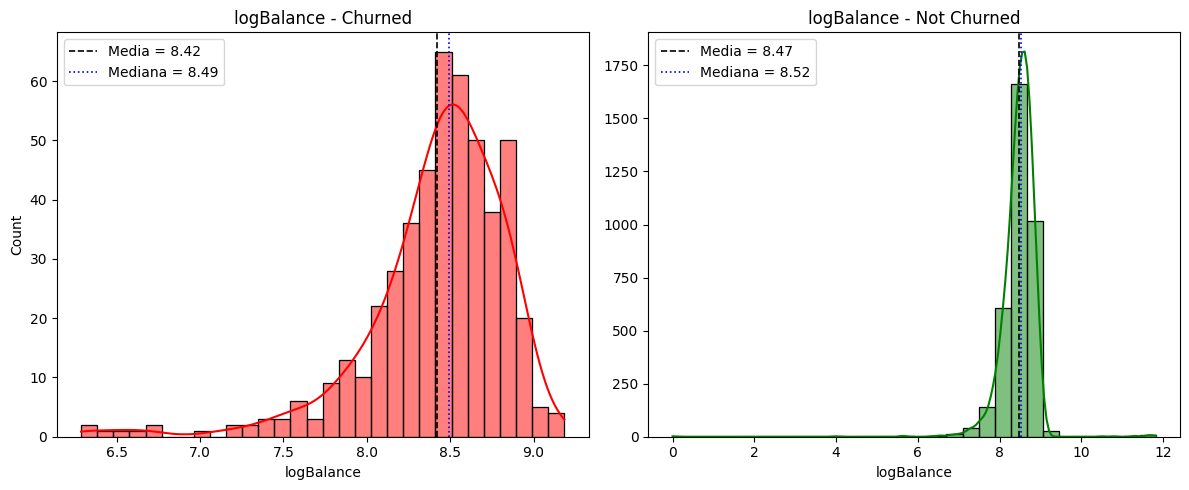

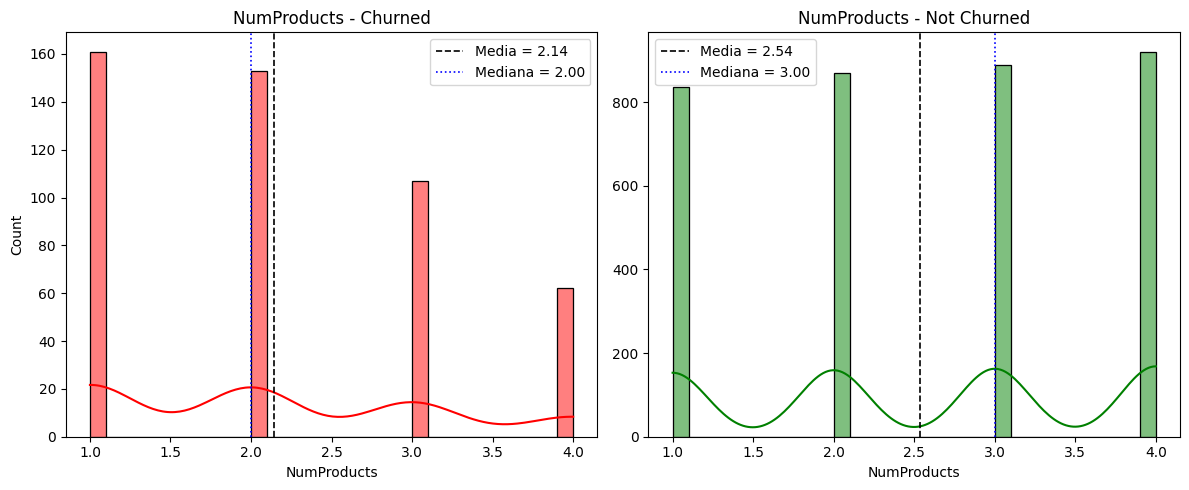

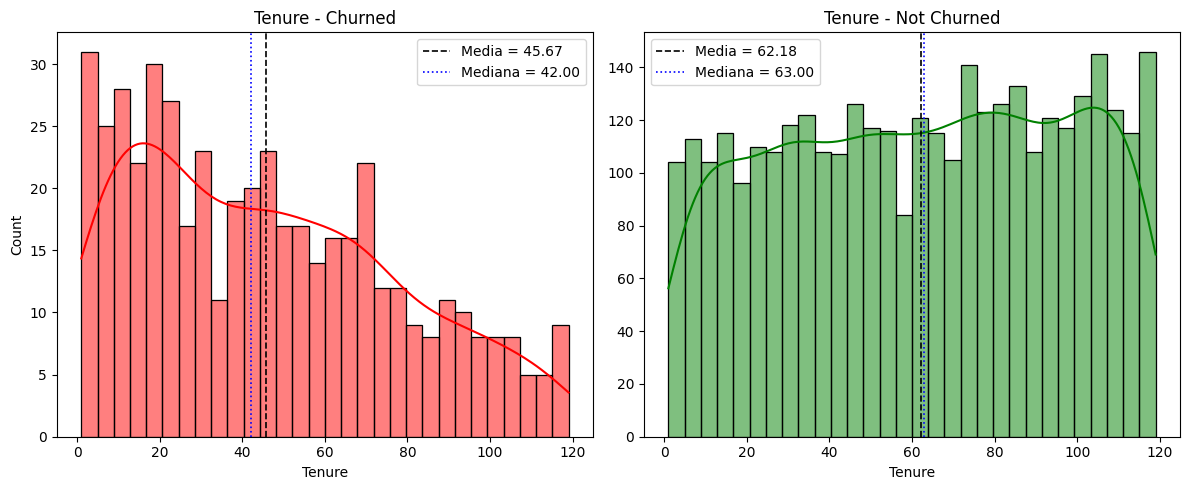

/tmp/ipykernel_24518/634903798.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


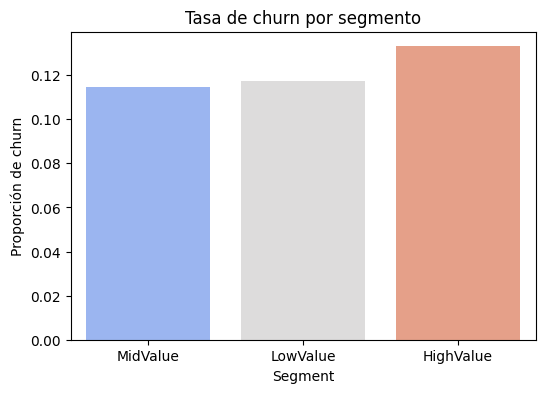

logBalance           t-test p = 0.0085  mannwhitney p = 0.0571
NumProducts          t-test p = 0.0000  mannwhitney p = 0.0000
Tenure               t-test p = 0.0000  mannwhitney p = 0.0000


In [11]:
churn_distributions(df1, ["logBalance", "NumProducts", "Tenure"], [])
statistical_tests(df1, ["logBalance", "NumProducts", "Tenure"])

#### 2

In [12]:
# Tabla 2x2 entre morosidad y churn
contingencia = pd.crosstab(df1["Delinquency_30d"], df1["Churn"])
a = contingencia.loc[1, 1]  # churned + moroso
b = contingencia.loc[1, 0]  # no churn + moroso
c = contingencia.loc[0, 1]  # churned + no moroso
d = contingencia.loc[0, 0]  # no churn + no moroso

odds_ratio = (a * d) / (b * c)
print(f"Odds Ratio = {odds_ratio:.2f}")
contingencia



Odds Ratio = 1.91


Churn,0,1
Delinquency_30d,,
0,3204,407
1,313,76


Al construir la tabla de contingencia entre Delinquency_30d y Churn, vemos que los clientes con morosidad presentan una proporción mayor de fuga. El cálculo del odds ratio arroja un valor de 1.91 lo que significa que los clientes con morosidad harta tienen más probabilidades de abandonar el banco que los que no presentan morosidad.

Esto sugiere que la morosidad está asociada a un mayor riesgo de fuga, por lo que sería importante reforzar las estrategias de retención y apoyo financiero a este grupo de clientes.

#### 3

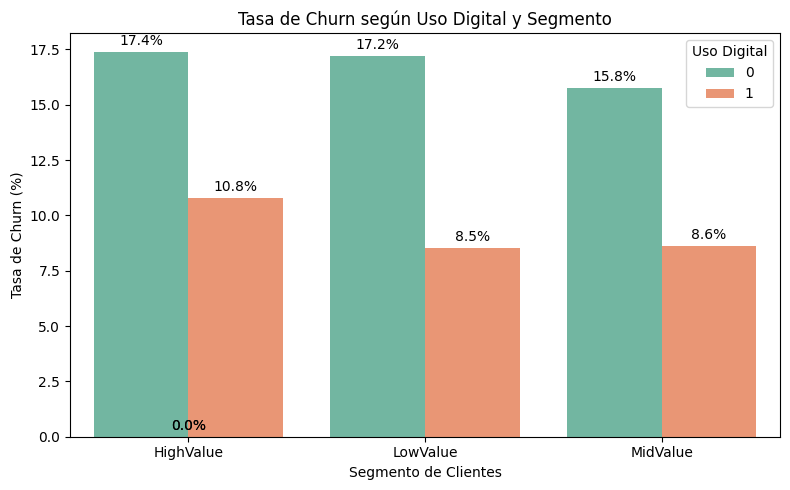

In [13]:
# Calcular proporción de churn dentro de cada combinación
churn_segment_usage = (
    df1.groupby(["Segment", "DigitalUsage"])["Churn"]
    .mean()
    .reset_index()
)

# Si Churn está en 0/1, el promedio = tasa de churn
churn_segment_usage["ChurnRate"] = churn_segment_usage["Churn"] * 100


import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
barplot = sns.barplot(
    data=churn_segment_usage,
    x="Segment",
    y="ChurnRate",
    hue="DigitalUsage",
    palette="Set2"
)

plt.title("Tasa de Churn según Uso Digital y Segmento")
plt.ylabel("Tasa de Churn (%)")
plt.xlabel("Segmento de Clientes")
plt.legend(title="Uso Digital")

# Añadir las etiquetas de porcentaje sobre las barras
for p in barplot.patches:
    height = p.get_height()
    barplot.annotate(f'{height:.1f}%',
                     (p.get_x() + p.get_width() / 2., height),
                     ha='center', va='bottom',
                     fontsize=10, color='black', xytext=(0,3),
                     textcoords='offset points')

plt.tight_layout()
plt.show()



#### 4

/tmp/ipykernel_24518/1560596866.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df1.groupby(["TenureGroup", "DigitalUsage"])["Churn"]


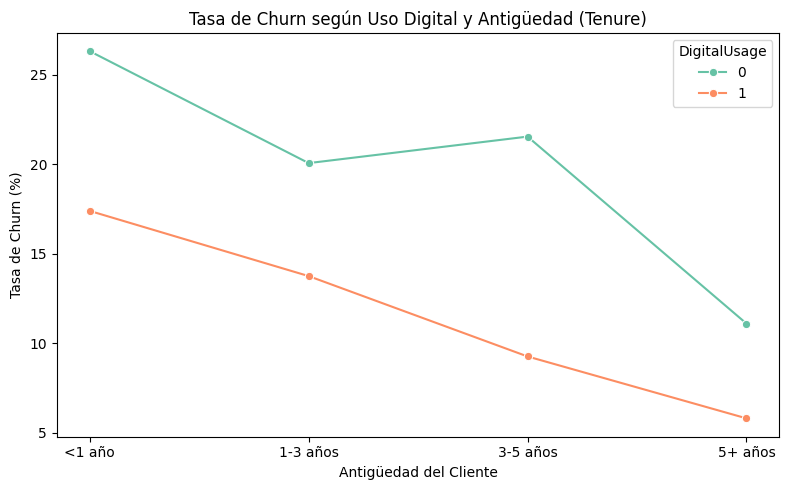

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Crear categorías de Tenure
df1["TenureGroup"] = pd.cut(df1["Tenure"], bins=[0, 12, 36, 60, 120],
                            labels=["<1 año", "1-3 años", "3-5 años", "5+ años"])

# Calcular tasa de churn por grupo
tenure_usage = (
    df1.groupby(["TenureGroup", "DigitalUsage"])["Churn"]
    .mean()
    .reset_index()
)
tenure_usage["ChurnRate"] = tenure_usage["Churn"] * 100

# Lineplot: evolución de churn según Tenure y uso digital
plt.figure(figsize=(8,5))
sns.lineplot(
    data=tenure_usage,
    x="TenureGroup",
    y="ChurnRate",
    hue="DigitalUsage",
    marker="o",
    palette="Set2"
)
plt.title("Tasa de Churn según Uso Digital y Antigüedad (Tenure)")
plt.ylabel("Tasa de Churn (%)")
plt.xlabel("Antigüedad del Cliente")
plt.tight_layout()
plt.show()


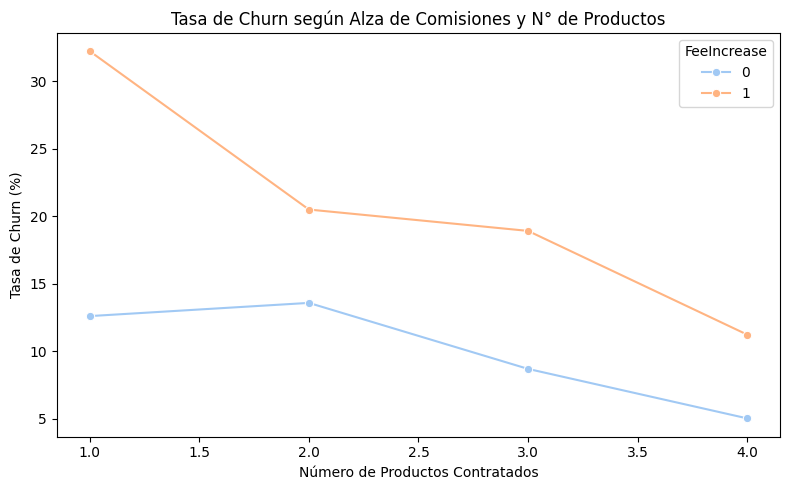

In [15]:

# Agrupar por FeeIncrease y cantidad de productos
fee_products = (
    df1.groupby(["FeeIncrease", "NumProducts"])["Churn"]
    .mean()
    .reset_index()
)
fee_products["ChurnRate"] = fee_products["Churn"] * 100

plt.figure(figsize=(8,5))
sns.lineplot(
    data=fee_products,
    x="NumProducts",
    y="ChurnRate",
    hue="FeeIncrease",
    marker="o",
    palette="pastel"
)
plt.title("Tasa de Churn según Alza de Comisiones y N° de Productos")
plt.ylabel("Tasa de Churn (%)")
plt.xlabel("Número de Productos Contratados")
plt.tight_layout()
plt.show()


/tmp/ipykernel_24518/1927050647.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tenure_usage = df1.groupby(["TenureGroup", "DigitalUsage"])["Churn"].mean().reset_index()


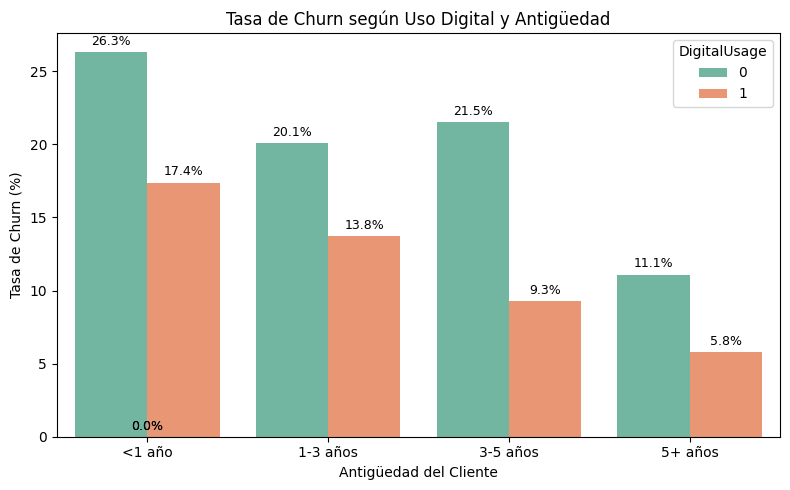

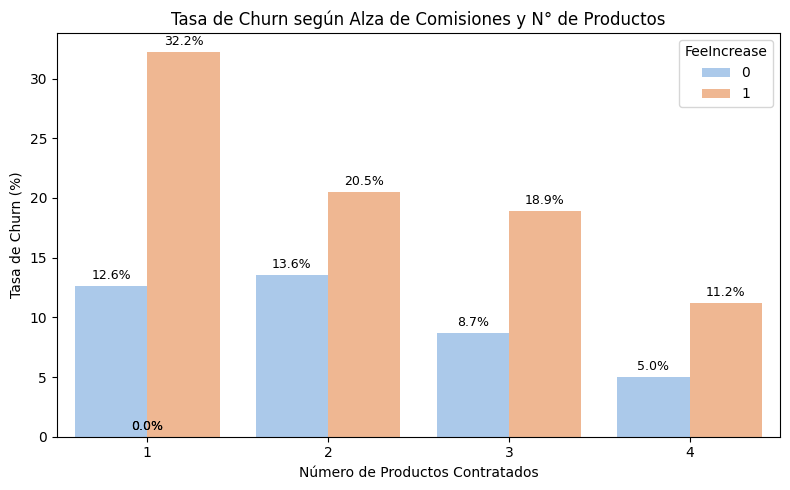

In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- Interacción Tenure x DigitalUsage --- #
# Categorizar Tenure
df1["TenureGroup"] = pd.cut(df1["Tenure"], bins=[0, 12, 36, 60, 120],
                            labels=["<1 año", "1-3 años", "3-5 años", "5+ años"])

# Calcular tasa de churn
tenure_usage = df1.groupby(["TenureGroup", "DigitalUsage"])["Churn"].mean().reset_index()
tenure_usage["ChurnRate"] = tenure_usage["Churn"] * 100

# Barplot agrupado con valores sobre las barras
plt.figure(figsize=(8,5))
barplot = sns.barplot(
    data=tenure_usage,
    x="TenureGroup",
    y="ChurnRate",
    hue="DigitalUsage",
    palette="Set2"
)
plt.title("Tasa de Churn según Uso Digital y Antigüedad")
plt.ylabel("Tasa de Churn (%)")
plt.xlabel("Antigüedad del Cliente")

# Añadir etiquetas sobre las barras
for p in barplot.patches:
    height = p.get_height()
    barplot.annotate(f'{height:.1f}%', 
                     (p.get_x() + p.get_width()/2., height), 
                     ha='center', va='bottom', fontsize=9, xytext=(0,3), textcoords='offset points')

plt.tight_layout()
plt.show()

# --- Interacción FeeIncrease x NumProducts --- #
fee_products = df1.groupby(["FeeIncrease", "NumProducts"])["Churn"].mean().reset_index()
fee_products["ChurnRate"] = fee_products["Churn"] * 100

plt.figure(figsize=(8,5))
barplot2 = sns.barplot(
    data=fee_products,
    x="NumProducts",
    y="ChurnRate",
    hue="FeeIncrease",
    palette="pastel"
)
plt.title("Tasa de Churn según Alza de Comisiones y N° de Productos")
plt.ylabel("Tasa de Churn (%)")
plt.xlabel("Número de Productos Contratados")

for p in barplot2.patches:
    height = p.get_height()
    barplot2.annotate(f'{height:.1f}%', 
                      (p.get_x() + p.get_width()/2., height),
                      ha='center', va='bottom', fontsize=9, xytext=(0,3), textcoords='offset points')

plt.tight_layout()
plt.show()


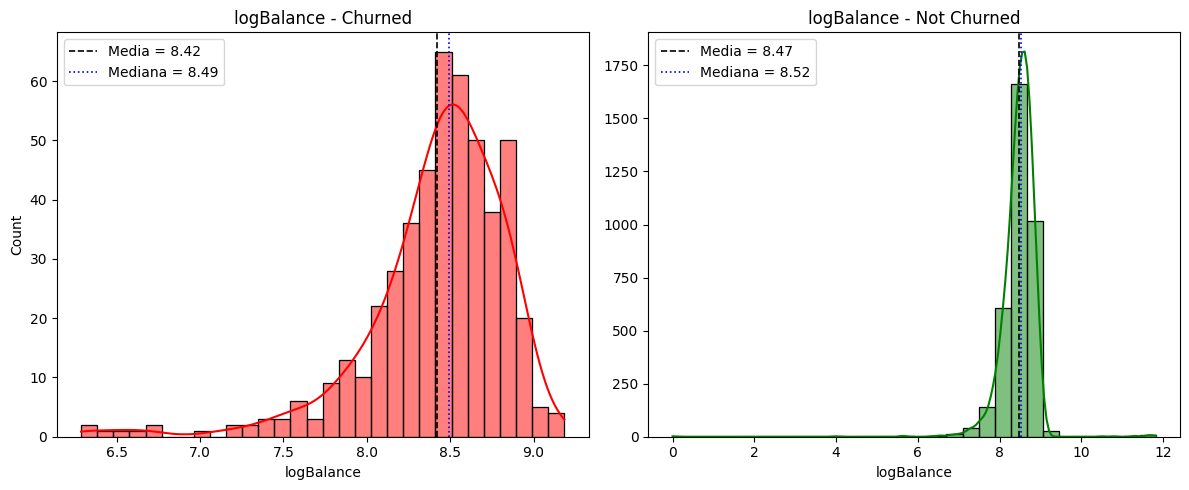

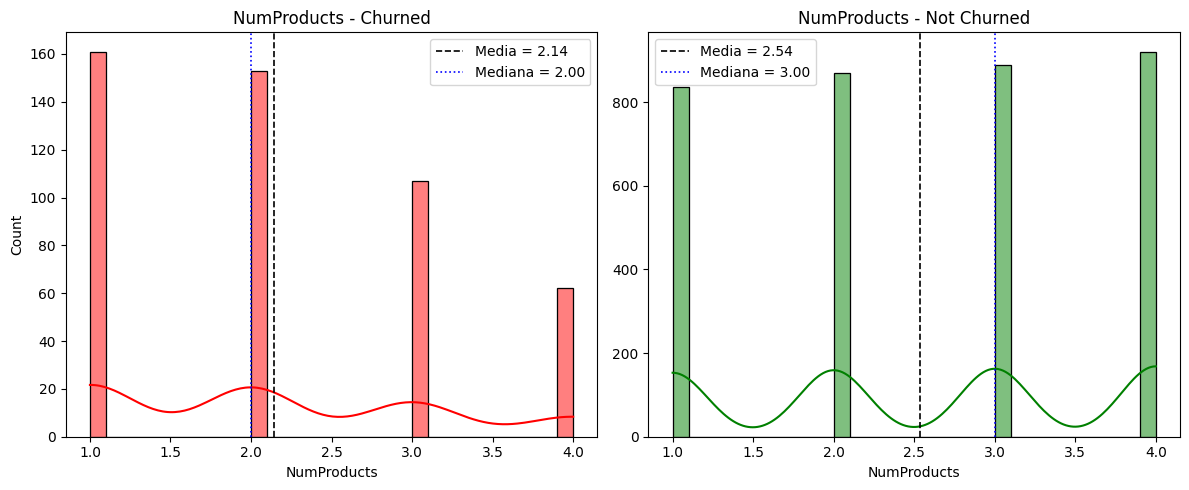

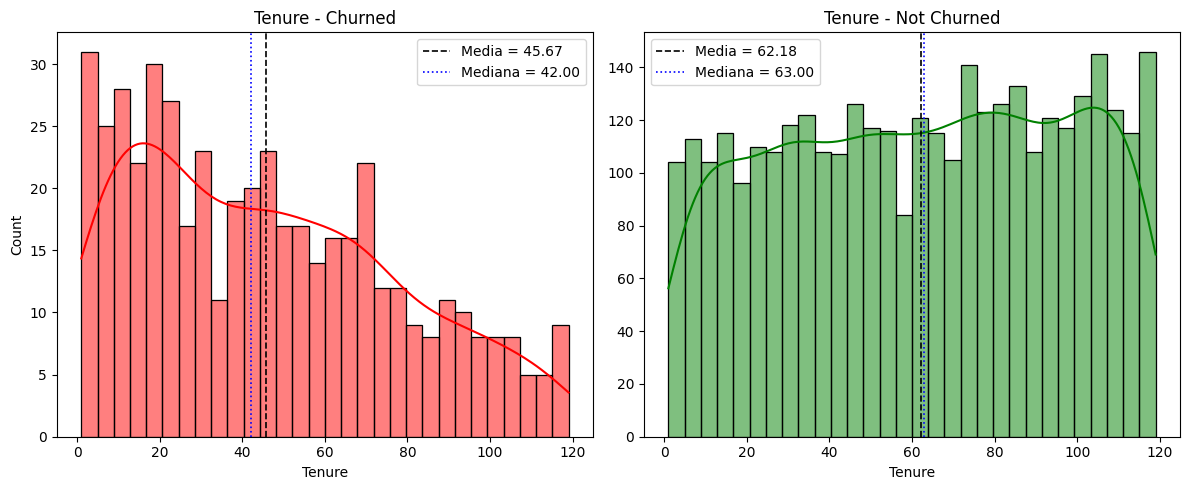

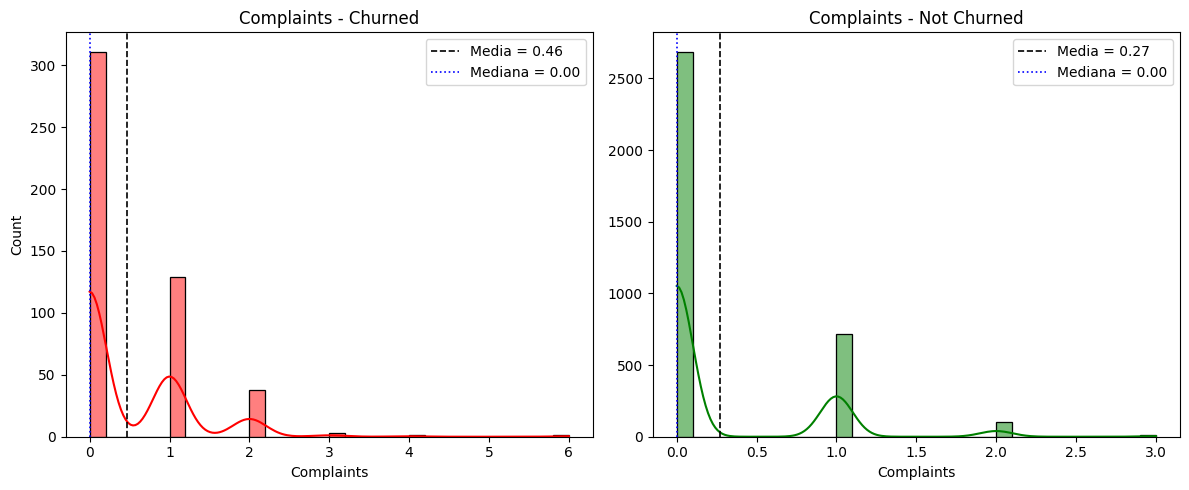

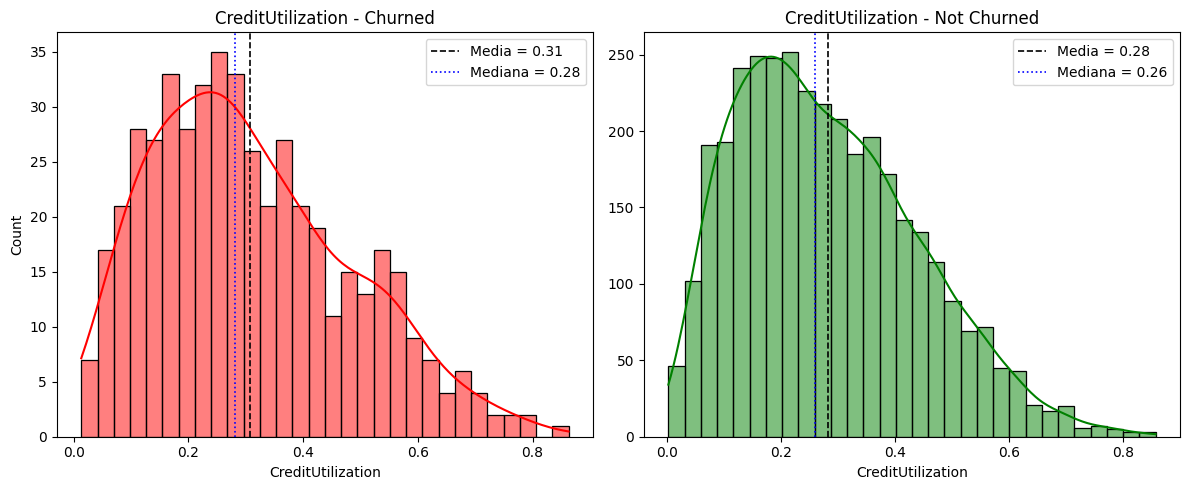

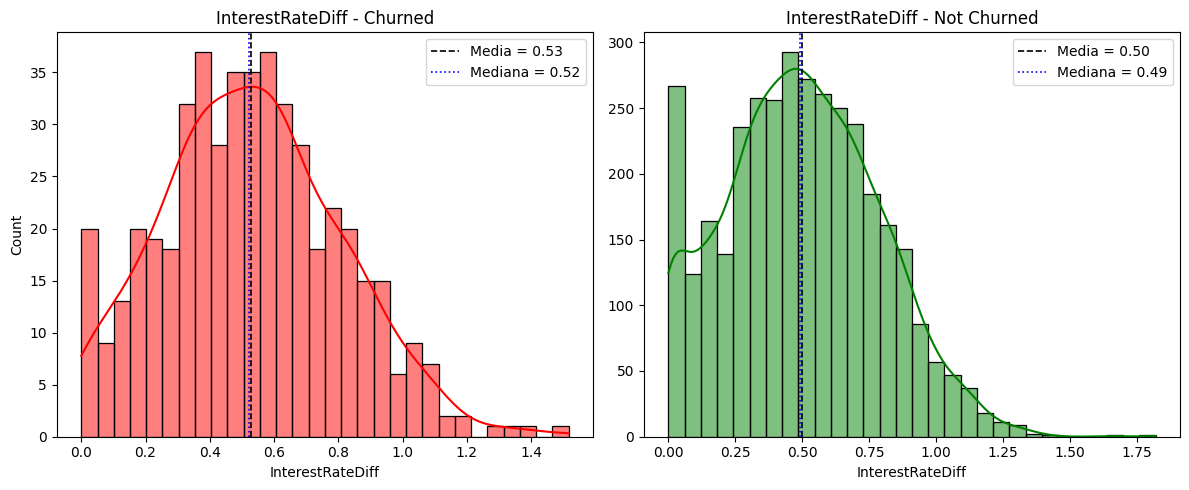

/tmp/ipykernel_24518/634903798.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


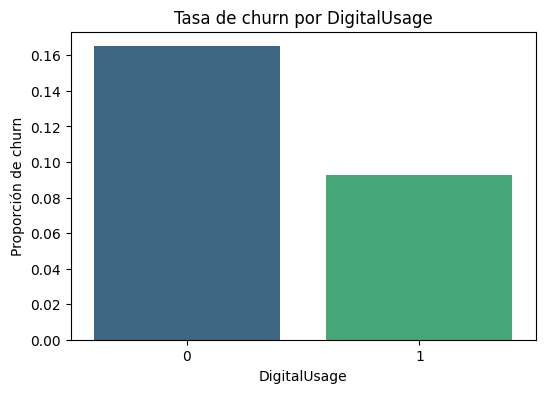

/tmp/ipykernel_24518/634903798.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


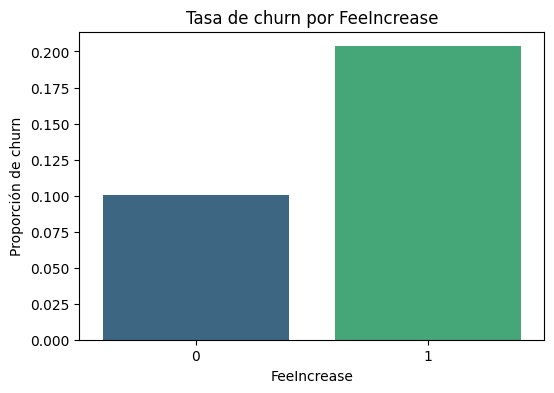

/tmp/ipykernel_24518/634903798.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


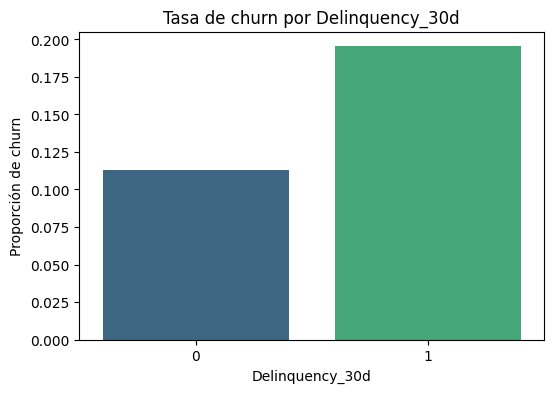

/tmp/ipykernel_24518/634903798.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


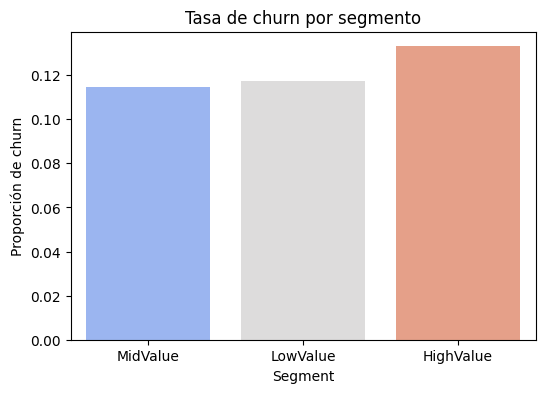

In [17]:

# Uso
churn_distributions(df1)


In [18]:

pd.crosstab(df1)

TypeError: crosstab() missing 1 required positional argument: 'columns'

In [ ]:
import pandas as pd

# 1) Cargar
df = pd.read_csv('fintrust_bank_data.csv')

# 2) Inspección rápida
print(df.shape)
print(df.columns)
print(df.head())
print(df.dtypes)

# 3) Asegurar columna Churn como 0/1
# Si Churn viene como 'Sí'/'No' o 'Y'/'N', adaptamos según el caso:
df['Churn'] = df['Churn'].replace({"Sí":1, "Si":1, "No":0, "sí":1, "SI":1, "N":0})
df['Churn'] = pd.to_numeric(df['Churn'], errors='coerce').fillna(0).astype(int)

# 4) Variables booleanas (asegurar 0/1)
bool_cols = ['DigitalUsage', 'FeeIncrease', 'Delinquency_30d']
for c in bool_cols:
    if c in df.columns:
        df[c] = df[c].replace({"Sí":1, "Si":1, "No":0, True:1, False:0})
        df[c] = pd.to_numeric(df[c], errors='coerce').fillna(0).astype(int)

# 5) Reemplazo/normalización de texto en Segment si existe
if 'Segment' in df.columns:
    # opción A: mapear a ordinal
    segment_map = {"HighValue":2, "MidValue":1, "LowValue":0,
                   "HIGH":2, "MID":1, "LOW":0}
    df['Segment_code'] = df['Segment'].map(segment_map)
    # Si prefieres dummies:
    df = pd.concat([df, pd.get_dummies(df['Segment'], prefix='Segment', dummy_na=False)], axis=1)

# 6) Relleno de NA razonable (ejemplo)
num_cols = df.select_dtypes(include=['number']).columns.tolist()
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# 7) Revisar distribuciones (opcional)
print(df[num_cols].describe())

# 8) Calcular churn rate global y por segmento
churn_rate_global = df['Churn'].mean()
print(f"Churn rate global: {churn_rate_global:.4f}  -> {churn_rate_global*100:.2f}%")

if 'Segment' in df.columns:
    churn_by_segment = df.groupby('Segment')['Churn'].agg(['mean','count']).rename(columns={'mean':'churn_rate'})
    churn_by_segment['churn_pct'] = churn_by_segment['churn_rate']*100
    print(churn_by_segment)

# 9) Preparar dataset para regresión logística
# Selecciona features relevantes (las de tu enunciado)
features = ['logBalance','NumProducts','DigitalUsage','Tenure',
            'FeeIncrease','Complaints','Delinquency_30d',
            'CreditUtilization','InterestRateDiff']
# añadir Segment_code si existe
if 'Segment_code' in df.columns:
    features.append('Segment_code')

# Asegurar que existan las columnas
features = [f for f in features if f in df.columns]

X = df[features].copy()
y = df['Churn'].copy()

# Escalado opcional (recomendado para coeficientes comparables)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)

# 10) Guardar dataset preprocesado
df_preproc = pd.concat([X_scaled, y], axis=1)
df_preproc.to_csv("fintual_users_dataset_selected_preprocessed.csv", index=False)
print("Preprocesado guardado en fintual_users_dataset_selected_preprocessed.csv")



(4000, 12)
Index(['Segment', 'Balance', 'logBalance', 'NumProducts', 'DigitalUsage',
       'Tenure', 'FeeIncrease', 'Complaints', 'Delinquency_30d',
       'CreditUtilization', 'InterestRateDiff', 'Churn'],
      dtype='object')
     Segment      Balance  logBalance  NumProducts  DigitalUsage  Tenure  \
0   MidValue  3516.317974    8.165454            4             0      97   
1   LowValue  4448.320023    8.400507            2             1      14   
2   MidValue  6931.887892    8.844032            1             0      61   
3  HighValue  5290.961629    8.573944            3             0       8   
4   MidValue  6380.346349    8.761134            3             1       8   

   FeeIncrease  Complaints  Delinquency_30d  CreditUtilization  \
0            0           2                0           0.083027   
1            1           1                0           0.362565   
2            0           0                1           0.325600   
3            0           0                0      

### Parte 4

In [21]:
fake_X = df1[['logBalance', 'NumProducts', 'DigitalUsage', 'Tenure',
        'FeeIncrease', 'Complaints', 'Delinquency_30d', 
        'CreditUtilization', 'InterestRateDiff', 'Segment']]
y = df1['Churn']
X = pd.get_dummies(fake_X, drop_first=True)

#### 2

In [ ]:
# Ya tenemos X_dummy y y definidos
# X_dummy = pd.get_dummies(X, drop_first=True)
# y = df1['Churn']

# Ejemplo de análisis visual variable por variable

pd.crosstab(X['Delinquency_30d'], y, normalize='index')

Churn,0,1
Delinquency_30d,,
0,0.887289,0.112711
1,0.804627,0.195373


In [ ]:
pd.crosstab(X['DigitalUsage'], y, normalize='index')

Churn,0,1
DigitalUsage,,
0,0.834939,0.165061
1,0.907491,0.092509


In [ ]:
pd.crosstab(X['FeeIncrease'], y, normalize='index')


Churn,0,1
FeeIncrease,,
0,0.899657,0.100343
1,0.796460,0.203540


In [ ]:
pd.crosstab(X['Segment_LowValue'], y, normalize='index')


Churn,0,1
Segment_LowValue,,
False,0.878441,0.121559
True,0.882660,0.117340


In [ ]:
pd.crosstab(X['Segment_MidValue'], y, normalize='index')


Churn,0,1
Segment_MidValue,,
False,0.873048,0.126952
True,0.885360,0.114640


#### 3

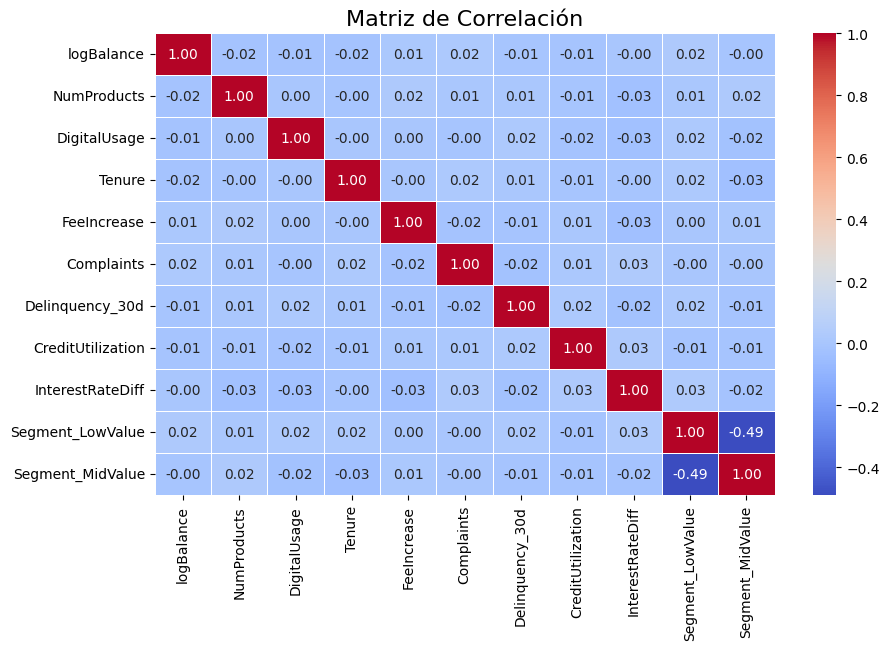

In [22]:
# Correlation matrix
correlation_matrix = pd.get_dummies(X, drop_first=True).corr()

# Set up the matplotlib figure
plt.figure(figsize=(10, 6))

# Create a heatmap for the correlation matrix
sns.heatmap(X.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

# Title for the heatmap
plt.title("Matriz de Correlación", fontsize=16)

# Show the heatmap
plt.show()

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values.astype(float), i)
                   for i in range(X.shape[1])]

print(vif_data)


             Variable        VIF
0          logBalance  18.957699
1         NumProducts   5.929605
2        DigitalUsage   2.559605
3              Tenure   4.010227
4         FeeIncrease   1.249553
5          Complaints   1.284169
6     Delinquency_30d   1.109949
7   CreditUtilization   4.149293
8    InterestRateDiff   4.071972
9    Segment_LowValue   1.632987
10   Segment_MidValue   2.651051


In [26]:
# Sacamos logBalance

CX = X.drop(columns=['logBalance'])
CX

,NumProducts,DigitalUsage,Tenure,FeeIncrease,Complaints,Delinquency_30d,CreditUtilization,InterestRateDiff,Segment_LowValue,Segment_MidValue
0,4,0,97,0,2,0,0.083027,0.634950,False,True
1,2,1,14,1,1,0,0.362565,1.077014,True,False
2,1,0,61,0,0,1,0.325600,1.228641,False,True
3,3,0,8,0,0,0,0.203439,0.541204,False,False
4,3,1,8,0,0,0,0.711838,0.898735,False,True
...,...,...,...,...,...,...,...,...,...,...
3995,2,1,96,0,1,0,0.550669,0.813068,False,False
3996,4,1,38,0,0,0,0.152240,0.254105,False,True
3997,3,1,55,0,0,0,0.292981,0.254084,False,True
3998,2,1,23,0,2,0,0.548641,0.200151,False,False


#### 4

In [24]:
# Selección de variables explicativas

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
import statsmodels.api as sm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.base.optimizer import Optimizer
from statsmodels.tools.sm_exceptions import ConvergenceWarning
import warnings

#Dividimos el conjunto de datos en 80% para entrenar y 20% para test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=45)

# Asegurar que todo sea numérico
X_train_sm = sm.add_constant(X_train).astype(float)
y_train = y_train.astype(float)

# Ajustar el modelo
model = sm.Logit(y_train, X_train_sm, penalty='l2')
result = model.fit()

print(result.summary())

np.exp(result.params)



Optimization terminated successfully.
         Current function value: 0.320328
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                  Churn   No. Observations:                 3200
Model:                          Logit   Df Residuals:                     3188
Method:                           MLE   Df Model:                           11
Date:                Sun, 19 Oct 2025   Pseudo R-squ.:                  0.1343
Time:                        01:12:39   Log-Likelihood:                -1025.0
converged:                       True   LL-Null:                       -1184.1
Covariance Type:            nonrobust   LLR p-value:                 1.353e-61
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 4.0174      1.228      3.271      0.001       1.611       6.424
logBalan

/home/potx8o/Desktop/UAI/Marketing/t2/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:130: ValueWarning: unknown kwargs ['penalty']
  warnings.warn(msg, ValueWarning)
/home/potx8o/Desktop/UAI/Marketing/t2/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:130: ValueWarning: unknown kwargs ['penalty']
  warnings.warn(msg, ValueWarning)


const                55.558935
logBalance            0.567646
NumProducts           0.684713
DigitalUsage          0.458647
Tenure                0.984620
FeeIncrease           2.813253
Complaints            1.906198
Delinquency_30d       2.251985
CreditUtilization     2.684526
InterestRateDiff      1.389542
Segment_LowValue      0.848312
Segment_MidValue      0.834494
dtype: float64

In [ ]:
summary_table = pd.DataFrame({
    'Coef': result.params,
    'OR': np.exp(result.params),
    '2.5% OR': np.exp(result.conf_int()[0]),
    '97.5% OR': np.exp(result.conf_int()[1])
})

summary_table


,Coef,OR,2.5% OR,97.5% OR
const,4.017444,55.558935,5.005568,616.672371
logBalance,-0.566257,0.567646,0.429258,0.750650
NumProducts,-0.378755,0.684713,0.616006,0.761084
DigitalUsage,-0.779474,0.458647,0.365587,0.575395
Tenure,-0.015500,0.984620,0.981213,0.988038
FeeIncrease,1.034341,2.813253,2.190369,3.613270
Complaints,0.645111,1.906198,1.597218,2.274950
Delinquency_30d,0.811812,2.251985,1.617963,3.134457
CreditUtilization,0.987504,2.684526,1.359278,5.301847
InterestRateDiff,0.328974,1.389542,0.936039,2.062764


#### 5 bla bla bla 

#### 6

In [ ]:
newX = X
newX["DigitalUsage_Tenure"]  = newX["DigitalUsage"] * newX["Tenure"]

In [ ]:

#Dividimos el conjunto de datos en 80% para entrenar y 20% para test
X_train, X_test, y_train, y_test = train_test_split(newX, y, test_size=0.2, random_state=45)

# Asegurar que todo sea numérico
X_train_sm = sm.add_constant(X_train).astype(float)
y_train = y_train.astype(float)

# Ajustar el modelo
model = sm.Logit(y_train, X_train_sm)
result = model.fit()

print(result.summary())

np.exp(result.params)


Optimization terminated successfully.
         Current function value: 0.319825
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                  Churn   No. Observations:                 3200
Model:                          Logit   Df Residuals:                     3187
Method:                           MLE   Df Model:                           12
Date:                Sat, 18 Oct 2025   Pseudo R-squ.:                  0.1357
Time:                        21:07:01   Log-Likelihood:                -1023.4
converged:                       True   LL-Null:                       -1184.1
Covariance Type:            nonrobust   LLR p-value:                 1.571e-61
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   3.8253      1.228      3.115      0.002       1.418       6.232
lo

const                  45.844738
logBalance              0.570521
NumProducts             0.683456
DigitalUsage            0.623371
Tenure                  0.987581
FeeIncrease             2.812422
Complaints              1.909875
Delinquency_30d         2.259958
CreditUtilization       2.706218
InterestRateDiff        1.385379
Segment_LowValue        0.859965
Segment_MidValue        0.831433
DigitalUsage_Tenure     0.993691
dtype: float64

##### 7

In [27]:

#Dividimos el conjunto de datos en 80% para entrenar y 20% para test
X_train, X_test, y_train, y_test = train_test_split(CX, y, test_size=0.2, random_state=45)

# Asegurar que todo sea numérico
X_train_sm = sm.add_constant(X_train).astype(float)
y_train = y_train.astype(float)

# Ajustar el modelo
model = sm.Logit(y_train, X_train_sm)
result = model.fit()

print(result.summary())

np.exp(result.params)


Optimization terminated successfully.
         Current function value: 0.322756
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                  Churn   No. Observations:                 3200
Model:                          Logit   Df Residuals:                     3189
Method:                           MLE   Df Model:                           10
Date:                Sun, 19 Oct 2025   Pseudo R-squ.:                  0.1278
Time:                        01:13:15   Log-Likelihood:                -1032.8
converged:                       True   LL-Null:                       -1184.1
Covariance Type:            nonrobust   LLR p-value:                 4.526e-59
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -0.7727      0.241     -3.203      0.001      -1.245      -0.300
NumProdu

const                0.461783
NumProducts          0.687516
DigitalUsage         0.460026
Tenure               0.984793
FeeIncrease          2.747326
Complaints           1.877425
Delinquency_30d      2.287981
CreditUtilization    2.742939
InterestRateDiff     1.410735
Segment_LowValue     0.822644
Segment_MidValue     0.819123
dtype: float64

In [28]:

# Reporte de m´etricas

X_test_sm = sm.add_constant(X_test).astype(float)
y_pred_prob = result.predict(X_test_sm)
y_pred = (y_pred_prob > 0.5).astype(int)


report = classification_report(y_test, y_pred, output_dict=True)
accuracy = report['accuracy']
sensitivity = report['1']['recall']
specificity = report['0']['recall']
precision = report['1']['precision']
f1_score = report['1']['f1-score']

# Pseudo R^2
pseudo_r2 = result.prsquared
print("Pseudo R²:", pseudo_r2)

# AIC y BIC
print("AIC:", result.aic)
print("BIC:", result.bic)


print(f"Accuracy: {accuracy:.4f}")
print(f"Sensitivity (Recall): {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"Precision: {precision:.4f}")
print(f"F1 Score: {f1_score:.4f}")
# Matriz de confusi´on y m´etricas
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nMatriz de Confusi´on:")
pd.DataFrame(conf_matrix)

Pseudo R²: 0.12775054201531333
AIC: 2087.6354695398513
BIC: 2154.4154365165173
Accuracy: 0.8850
Sensitivity (Recall): 0.0319
Specificity: 0.9986
Precision: 0.7500
F1 Score: 0.0612

Matriz de Confusi´on:


,0,1
0,705,1
1,91,3


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Predicción de probabilidades
X_test_sm = sm.add_constant(X_test)  # recordar agregar constante
y_pred_prob = result.predict(X_test_sm.astype(float))

# Convertir a predicción binaria usando un umbral de 0.5
y_pred = (y_pred_prob >= 0.5).astype(int)

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
print("Matriz de confusión:\n", cm)

# Métricas de clasificación
print(classification_report(y_test, y_pred))


Matriz de confusión:
 [[703   3]
 [ 92   2]]
              precision    recall  f1-score   support

           0       0.88      1.00      0.94       706
           1       0.40      0.02      0.04        94

    accuracy                           0.88       800
   macro avg       0.64      0.51      0.49       800
weighted avg       0.83      0.88      0.83       800

